# Softmax and Multiclass Classification

**Learning Objectives:**
- Understand the softmax function and its properties
- Master one-hot encoding for categorical labels
- Learn categorical cross-entropy loss for multiclass problems
- Bridge from binary to multiclass classification naturally
- Build a complete multiclass classifier from scratch

By the end of this notebook, you'll have **deep intuitions** about how multiclass classification works and why softmax + cross-entropy is the standard approach.

## Part 1: From Binary to Multiclass

### What You Already Know (Binary Classification)

In logistic regression, you learned to classify between **two classes**:
- **Input**: features $x$
- **Output**: probability $p$ that example belongs to class 1
- **Activation**: Sigmoid function $\sigma(z) = \frac{1}{1 + e^{-z}}$ squashes output to [0, 1]
- **Loss**: Binary cross-entropy

### The New Challenge (Multiclass Classification)

But what if we have **more than two classes**?

**Real-World Examples:**
1. **Image classification**: Cat, dog, bird, horse, deer (5 classes)
2. **Handwriting recognition**: Digits 0-9 (10 classes)
3. **Sentiment analysis**: Very negative, negative, neutral, positive, very positive (5 classes)
4. **Iris species**: Setosa, Versicolor, Virginica (3 classes)

### The Key Questions

1. How do we output **probabilities for multiple classes**?
2. How do we ensure these probabilities **sum to 1**?
3. How do we measure **how wrong** our predictions are?

**Spoiler**: Softmax + categorical cross-entropy!

## Part 2: Setup

In [1]:
# Setup
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from aiml_notebooks import set_seed

# Set seed for reproducibility
set_seed(42)

# Configure matplotlib
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("✓ Libraries loaded and seed set for reproducibility")

✓ Libraries loaded and seed set for reproducibility


## Part 3: Understanding the Softmax Function

### The Problem

Imagine your model outputs **raw scores** (logits) for each class:
- Cat: 2.3
- Dog: 1.5
- Bird: 0.8

These numbers don't sum to 1 and aren't probabilities. We need to convert them!

### The Softmax Function

The **softmax function** converts raw scores into probabilities:

$$\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$$

where:
- $z_i$ = raw score (logit) for class $i$
- $K$ = number of classes
- $e^{z_i}$ = exponential makes all values positive
- Division by sum ensures outputs sum to 1

### Why "Soft"max?

- **Softmax** ≈ smooth version of **argmax**
- **Argmax** picks the largest: [2.3, 1.5, 0.8] → [1, 0, 0]
- **Softmax** distributes probability: [2.3, 1.5, 0.8] → [0.61, 0.27, 0.13]
- Higher scores get more probability, but others get some too!

### Implementing Softmax

In [2]:
def softmax(z):
    """
    Compute softmax function for an array of logits.
    
    Args:
        z: array of shape (K,) or (n, K) where K is number of classes
    
    Returns:
        probabilities: same shape as z, each row sums to 1
    """
    # Numerical stability trick: subtract max to prevent overflow
    z_shifted = z - np.max(z, axis=-1, keepdims=True)
    exp_z = np.exp(z_shifted)
    return exp_z / np.sum(exp_z, axis=-1, keepdims=True)

# Test with a simple example
logits = np.array([2.3, 1.5, 0.8])
probs = softmax(logits)

print("Input logits:      ", logits)
print("Softmax output:    ", probs)
print("Sum of probabilities:", probs.sum())
print("\n✓ All probabilities are positive and sum to 1!")

Input logits:       [2.3 1.5 0.8]
Softmax output:     [0.59792194 0.26866364 0.13341442]
Sum of probabilities: 1.0

✓ All probabilities are positive and sum to 1!


### Properties of Softmax

Let's visualize how softmax behaves!

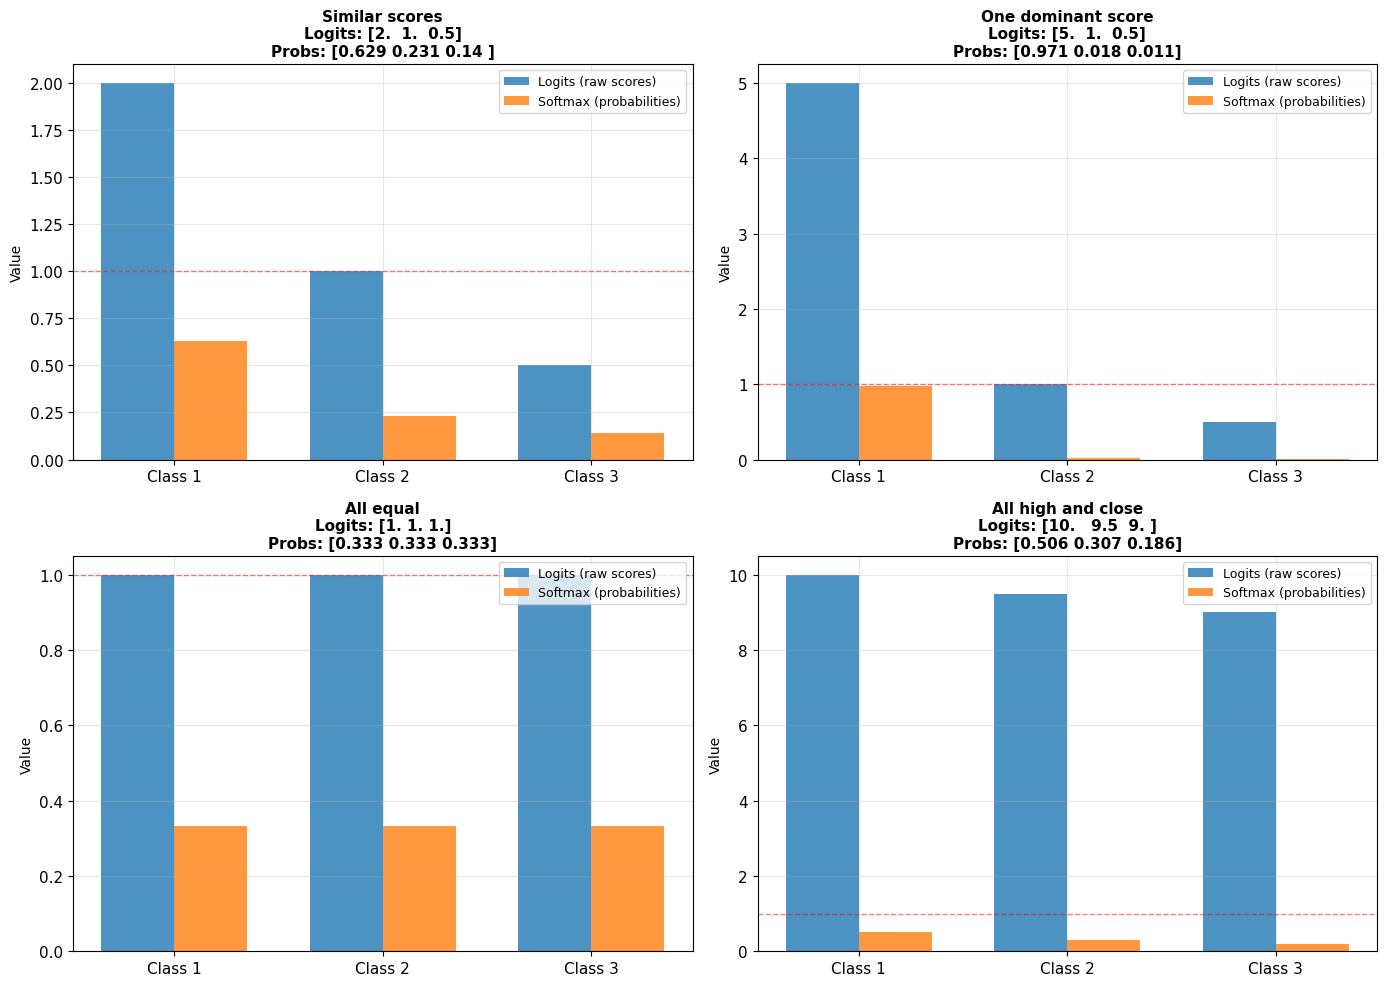

In [3]:
# Visualize softmax behavior with different inputs
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

test_cases = [
    ([2.0, 1.0, 0.5], "Similar scores"),
    ([5.0, 1.0, 0.5], "One dominant score"),
    ([1.0, 1.0, 1.0], "All equal"),
    ([10.0, 9.5, 9.0], "All high and close")
]

for idx, (logits, title) in enumerate(test_cases):
    ax = axes[idx // 2, idx % 2]
    logits = np.array(logits)
    probs = softmax(logits)
    
    x = ['Class 1', 'Class 2', 'Class 3']
    
    # Plot logits and probabilities side by side
    x_pos = np.arange(len(x))
    width = 0.35
    
    ax.bar(x_pos - width/2, logits, width, label='Logits (raw scores)', alpha=0.8)
    ax.bar(x_pos + width/2, probs, width, label='Softmax (probabilities)', alpha=0.8)
    
    ax.set_ylabel('Value', fontsize=10)
    ax.set_title(f'{title}\nLogits: {logits}\nProbs: {probs.round(3)}', 
                 fontsize=11, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=1.0, color='r', linestyle='--', alpha=0.5, linewidth=1)

plt.tight_layout()
plt.show()

### Key Insights

1. **All probabilities positive**: Exponential ensures $e^{z_i} > 0$
2. **Sum to 1**: Division by sum enforces this
3. **Preserves order**: If $z_i > z_j$, then $\text{softmax}(z_i) > \text{softmax}(z_j)$
4. **Amplifies differences**: Larger gaps in logits → more extreme probability differences
5. **Equal inputs**: All equal logits → uniform distribution

### 🤔 Reflection Question

**Q:** What happens when one logit is much larger than others (e.g., [100, 1, 1])? Why is this called "confident"?

## Part 4: The Temperature Parameter

Softmax has an optional **temperature** parameter $T$ that controls how "sharp" or "soft" the distribution is:

$$\text{softmax}(z_i, T) = \frac{e^{z_i/T}}{\sum_{j=1}^{K} e^{z_j/T}}$$

- **$T < 1$**: Sharpens distribution (more confident)
- **$T = 1$**: Standard softmax
- **$T > 1$**: Softens distribution (less confident)
- **$T \to 0$**: Approaches argmax (one-hot)
- **$T \to \infty$**: Approaches uniform distribution

### Visualizing Temperature

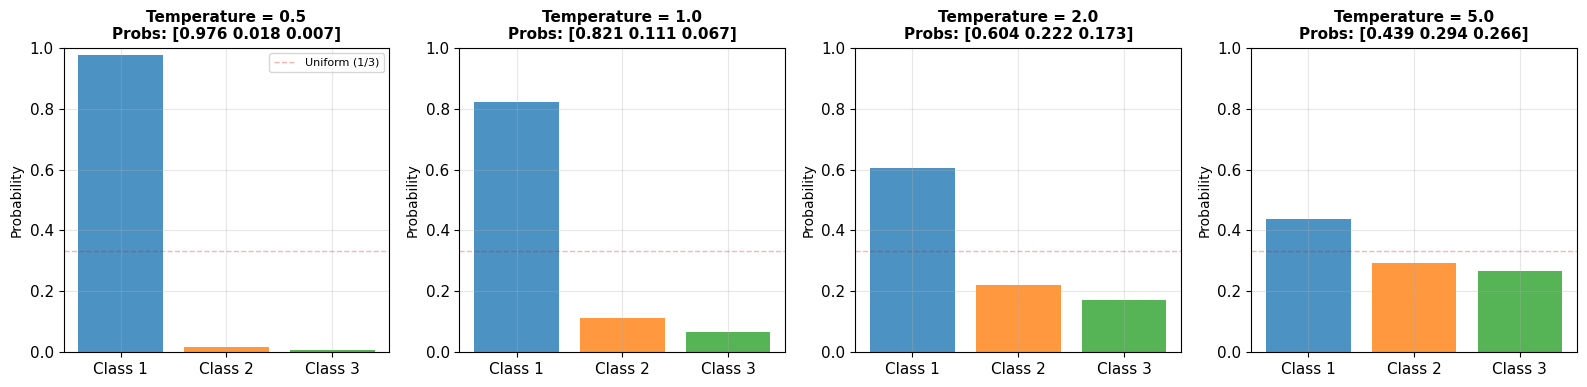


🔥 Lower temperature → sharper (more confident)
❄️  Higher temperature → softer (less confident)


In [4]:
def softmax_with_temperature(z, T=1.0):
    """Softmax with temperature parameter."""
    z_T = z / T
    z_shifted = z_T - np.max(z_T, axis=-1, keepdims=True)
    exp_z = np.exp(z_shifted)
    return exp_z / np.sum(exp_z, axis=-1, keepdims=True)

# Test different temperatures
logits = np.array([3.0, 1.0, 0.5])
temperatures = [0.5, 1.0, 2.0, 5.0]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for idx, T in enumerate(temperatures):
    probs = softmax_with_temperature(logits, T)
    
    axes[idx].bar(['Class 1', 'Class 2', 'Class 3'], probs, alpha=0.8, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    axes[idx].set_ylim([0, 1])
    axes[idx].set_ylabel('Probability', fontsize=10)
    axes[idx].set_title(f'Temperature = {T}\nProbs: {probs.round(3)}', fontsize=11, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].axhline(y=1/3, color='r', linestyle='--', alpha=0.3, linewidth=1, label='Uniform (1/3)')
    if idx == 0:
        axes[idx].legend(fontsize=8)

plt.tight_layout()
plt.show()

print("\n🔥 Lower temperature → sharper (more confident)")
print("❄️  Higher temperature → softer (less confident)")

### 🧪 When Is Temperature Useful?

- **Knowledge distillation**: Student learns from soft teacher predictions (T > 1)
- **Text generation**: Control randomness (low T = conservative, high T = creative)
- **Calibration**: Adjust confidence levels without retraining

## Part 5: One-Hot Encoding

Before we can train a classifier, we need to represent our labels in a way the model can understand.

### The Problem

Classes are categorical:
- "Setosa", "Versicolor", "Virginica"
- or numerically: 0, 1, 2

But we need them as **probability distributions** to compare with softmax outputs!

### One-Hot Encoding

**One-hot encoding** creates a vector with:
- 1 at the true class position
- 0 everywhere else

**Example**: For 3 classes:
- Class 0 (Setosa)     → [1, 0, 0]
- Class 1 (Versicolor) → [0, 1, 0]
- Class 2 (Virginica)  → [0, 0, 1]

This represents a **deterministic probability distribution** (100% sure it's that class).

### Implementing One-Hot Encoding

In [5]:
def one_hot_encode(labels, num_classes):
    """
    Convert integer labels to one-hot encoded vectors.
    
    Args:
        labels: array of shape (n,) with integer class labels
        num_classes: total number of classes
    
    Returns:
        one_hot: array of shape (n, num_classes)
    """
    n = len(labels)
    one_hot = np.zeros((n, num_classes))
    one_hot[np.arange(n), labels] = 1
    return one_hot

# Test it
labels = np.array([0, 1, 2, 1, 0])
one_hot = one_hot_encode(labels, num_classes=3)

print("Original labels:")
print(labels)
print("\nOne-hot encoded:")
print(one_hot)
print("\nEach row sums to:", one_hot.sum(axis=1))

Original labels:
[0 1 2 1 0]

One-hot encoded:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]]

Each row sums to: [1. 1. 1. 1. 1.]


### Visualizing One-Hot Encoding

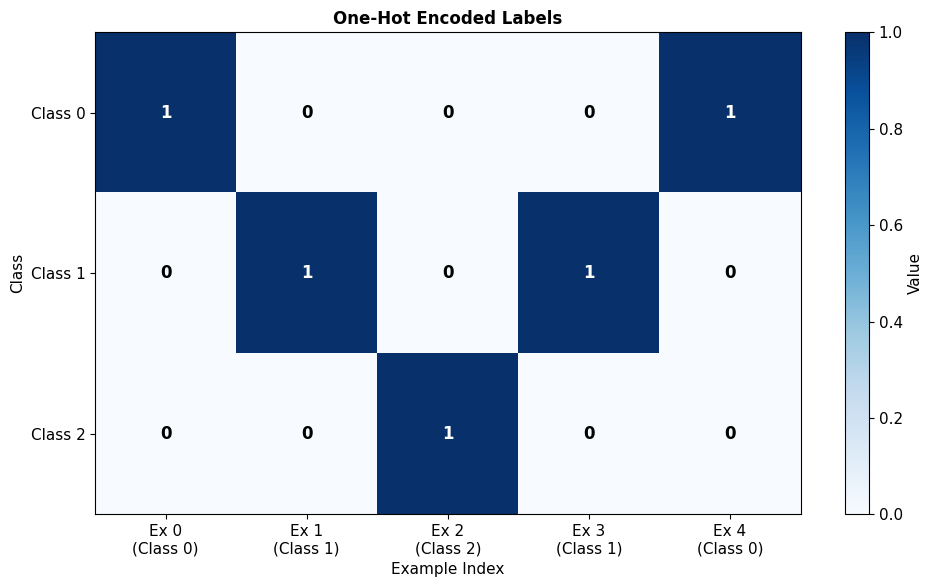

In [6]:
# Visualize one-hot encoding
fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(one_hot.T, cmap='Blues', aspect='auto', vmin=0, vmax=1)
ax.set_xlabel('Example Index', fontsize=11)
ax.set_ylabel('Class', fontsize=11)
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['Class 0', 'Class 1', 'Class 2'])
ax.set_xticks(range(len(labels)))
ax.set_xticklabels([f'Ex {i}\n(Class {labels[i]})' for i in range(len(labels))])
ax.set_title('One-Hot Encoded Labels', fontsize=12, fontweight='bold')

# Add text annotations
for i in range(len(labels)):
    for j in range(3):
        text = ax.text(i, j, int(one_hot[i, j]), ha="center", va="center", 
                      color="white" if one_hot[i, j] == 1 else "black", fontsize=12, fontweight='bold')

plt.colorbar(im, ax=ax, label='Value')
plt.tight_layout()
plt.show()

### Key Insights

1. **Sparse representation**: Only one non-zero entry per example
2. **Mutually exclusive**: Exactly one class per example
3. **Same shape as softmax output**: Both are (n, K) arrays
4. **Enables comparison**: Can compute loss between prediction and truth

### 🤔 Reflection Question

**Q:** Why do we need one-hot encoding? Why not just use integer labels directly?

## Part 6: Categorical Cross-Entropy Loss

Now we can measure how wrong our predictions are!

### The Intuition

Cross-entropy measures the **distance** between two probability distributions:
- **True distribution**: One-hot encoded label (e.g., [0, 1, 0])
- **Predicted distribution**: Softmax output (e.g., [0.2, 0.6, 0.2])

### The Formula

**Categorical cross-entropy** for a single example:

$$L = -\sum_{i=1}^{K} y_i \log(\hat{y}_i)$$

where:
- $y_i$ = true probability for class $i$ (from one-hot: either 0 or 1)
- $\hat{y}_i$ = predicted probability for class $i$ (from softmax)
- $K$ = number of classes

### Simplification

Since $y_i = 1$ only for the true class and $y_i = 0$ elsewhere:

$$L = -\log(\hat{y}_{\text{true class}})$$

**Intuition**: We only care about the predicted probability of the **true class**!

### Why the Negative Log?

- **High confidence, correct**: $\hat{y} = 0.9$ → $L = -\log(0.9) = 0.10$ (low loss) ✓
- **Low confidence, correct**: $\hat{y} = 0.1$ → $L = -\log(0.1) = 2.30$ (high loss) ✗
- **Perfect prediction**: $\hat{y} = 1.0$ → $L = -\log(1.0) = 0$ (zero loss) ✓✓

### Implementing Cross-Entropy Loss

In [7]:
def cross_entropy_loss(y_true_onehot, y_pred_probs):
    """
    Compute categorical cross-entropy loss.
    
    Args:
        y_true_onehot: one-hot encoded true labels, shape (n, K)
        y_pred_probs: predicted probabilities from softmax, shape (n, K)
    
    Returns:
        loss: scalar loss value
    """
    # Add small epsilon to prevent log(0)
    epsilon = 1e-15
    y_pred_probs = np.clip(y_pred_probs, epsilon, 1 - epsilon)
    
    # Compute cross-entropy
    n = len(y_true_onehot)
    loss = -np.sum(y_true_onehot * np.log(y_pred_probs)) / n
    
    return loss

# Test with examples
true_label = np.array([[0, 1, 0]])  # True class is 1

# Good prediction (confident and correct)
pred_good = np.array([[0.1, 0.8, 0.1]])
loss_good = cross_entropy_loss(true_label, pred_good)

# Bad prediction (confident and wrong)
pred_bad = np.array([[0.8, 0.1, 0.1]])
loss_bad = cross_entropy_loss(true_label, pred_bad)

# Uncertain prediction
pred_uncertain = np.array([[0.33, 0.34, 0.33]])
loss_uncertain = cross_entropy_loss(true_label, pred_uncertain)

print("True label: Class 1 (one-hot: [0, 1, 0])\n")
print(f"Good prediction     [0.1, 0.8, 0.1] → Loss = {loss_good:.4f}")
print(f"Uncertain prediction [0.33, 0.34, 0.33] → Loss = {loss_uncertain:.4f}")
print(f"Bad prediction      [0.8, 0.1, 0.1] → Loss = {loss_bad:.4f}")
print("\n✓ Lower loss = better prediction!")

True label: Class 1 (one-hot: [0, 1, 0])

Good prediction     [0.1, 0.8, 0.1] → Loss = 0.2231
Uncertain prediction [0.33, 0.34, 0.33] → Loss = 1.0788
Bad prediction      [0.8, 0.1, 0.1] → Loss = 2.3026

✓ Lower loss = better prediction!


### Visualizing the Loss Landscape

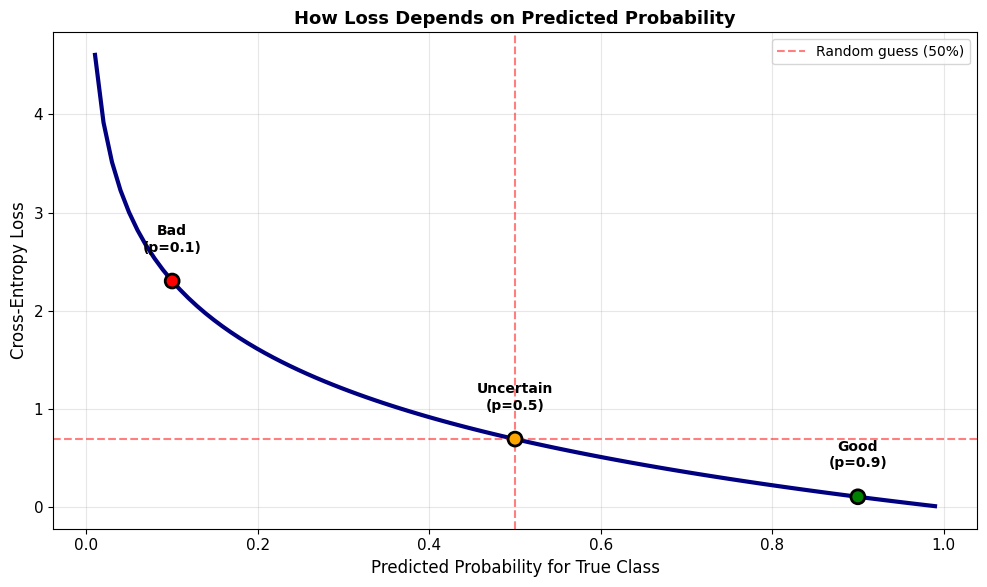

🔍 Key Observations:
  • Loss approaches 0 as prediction approaches 1 (perfect)
  • Loss grows rapidly as prediction approaches 0 (terrible)
  • Loss is convex (has unique minimum)
  • Heavily penalizes confident wrong predictions


In [8]:
# Plot loss vs predicted probability for true class
prob_true_class = np.linspace(0.01, 0.99, 100)
losses = -np.log(prob_true_class)

plt.figure(figsize=(10, 6))
plt.plot(prob_true_class, losses, linewidth=3, color='navy')
plt.xlabel('Predicted Probability for True Class', fontsize=12)
plt.ylabel('Cross-Entropy Loss', fontsize=12)
plt.title('How Loss Depends on Predicted Probability', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)

# Add annotations
plt.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Random guess (50%)')
plt.axhline(y=-np.log(0.5), color='red', linestyle='--', alpha=0.5)
plt.scatter([0.1, 0.5, 0.9], [-np.log(0.1), -np.log(0.5), -np.log(0.9)], 
           s=100, c=['red', 'orange', 'green'], zorder=5, edgecolors='black', linewidth=2)
plt.text(0.1, -np.log(0.1) + 0.3, 'Bad\n(p=0.1)', ha='center', fontsize=10, fontweight='bold')
plt.text(0.5, -np.log(0.5) + 0.3, 'Uncertain\n(p=0.5)', ha='center', fontsize=10, fontweight='bold')
plt.text(0.9, -np.log(0.9) + 0.3, 'Good\n(p=0.9)', ha='center', fontsize=10, fontweight='bold')

plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("🔍 Key Observations:")
print("  • Loss approaches 0 as prediction approaches 1 (perfect)")
print("  • Loss grows rapidly as prediction approaches 0 (terrible)")
print("  • Loss is convex (has unique minimum)")
print("  • Heavily penalizes confident wrong predictions")

## Part 7: The Iris Dataset

Now let's apply everything to a real multiclass problem!

### About the Iris Dataset

The **Iris dataset** is a classic machine learning dataset:
- **150 examples** of iris flowers
- **3 species**: Setosa, Versicolor, Virginica (50 examples each)
- **4 features**: Sepal length, sepal width, petal length, petal width (in cm)
- **Goal**: Predict species from measurements

This is a **3-class classification problem** - perfect for learning multiclass!

### Loading and Exploring the Data

In [9]:
# Load iris dataset
iris = load_iris()
X = iris.data  # Features: (150, 4)
y = iris.target  # Labels: (150,) with values 0, 1, 2
feature_names = iris.feature_names
class_names = iris.target_names

print("Dataset Information:")
print(f"  Number of examples: {len(X)}")
print(f"  Number of features: {X.shape[1]}")
print(f"  Number of classes: {len(class_names)}")
print(f"\nFeatures: {feature_names}")
print(f"Classes: {class_names}")
print(f"\nLabel distribution: {np.bincount(y)}")

# Show first few examples
print("\nFirst 5 examples:")
for i in range(5):
    print(f"  Example {i}: features={X[i]}, class={class_names[y[i]]} (label={y[i]})")

Dataset Information:
  Number of examples: 150
  Number of features: 4
  Number of classes: 3

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']

Label distribution: [50 50 50]

First 5 examples:
  Example 0: features=[5.1 3.5 1.4 0.2], class=setosa (label=0)
  Example 1: features=[4.9 3.  1.4 0.2], class=setosa (label=0)
  Example 2: features=[4.7 3.2 1.3 0.2], class=setosa (label=0)
  Example 3: features=[4.6 3.1 1.5 0.2], class=setosa (label=0)
  Example 4: features=[5.  3.6 1.4 0.2], class=setosa (label=0)


### Visualizing the Dataset

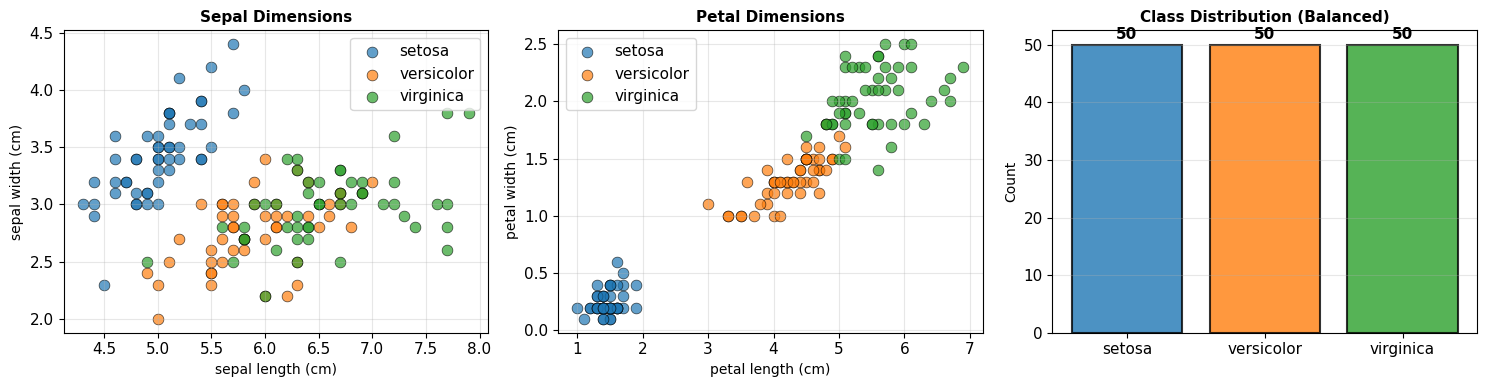


🔍 Observations:
  • Setosa (blue) is clearly separated by petal dimensions
  • Versicolor and Virginica overlap somewhat
  • Classes are perfectly balanced (50 examples each)


In [10]:
# Visualize the dataset (first 2 features for simplicity)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Sepal dimensions
for i, class_name in enumerate(class_names):
    mask = y == i
    axes[0].scatter(X[mask, 0], X[mask, 1], s=60, label=class_name, alpha=0.7, edgecolors='black', linewidth=0.5)
axes[0].set_xlabel(feature_names[0], fontsize=10)
axes[0].set_ylabel(feature_names[1], fontsize=10)
axes[0].set_title('Sepal Dimensions', fontsize=11, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Petal dimensions
for i, class_name in enumerate(class_names):
    mask = y == i
    axes[1].scatter(X[mask, 2], X[mask, 3], s=60, label=class_name, alpha=0.7, edgecolors='black', linewidth=0.5)
axes[1].set_xlabel(feature_names[2], fontsize=10)
axes[1].set_ylabel(feature_names[3], fontsize=10)
axes[1].set_title('Petal Dimensions', fontsize=11, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Class distribution
class_counts = np.bincount(y)
axes[2].bar(class_names, class_counts, alpha=0.8, color=['#1f77b4', '#ff7f0e', '#2ca02c'], edgecolor='black', linewidth=1.5)
axes[2].set_ylabel('Count', fontsize=10)
axes[2].set_title('Class Distribution (Balanced)', fontsize=11, fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='y')
for i, count in enumerate(class_counts):
    axes[2].text(i, count + 1, str(count), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n🔍 Observations:")
print("  • Setosa (blue) is clearly separated by petal dimensions")
print("  • Versicolor and Virginica overlap somewhat")
print("  • Classes are perfectly balanced (50 examples each)")

## Part 8: Building a Multiclass Classifier

Let's build a **linear multiclass classifier** from scratch!

### The Model

For each class $k$, we compute a score:

$$z_k = w_k^T x + b_k$$

Then apply softmax:

$$\hat{y}_k = \text{softmax}(z)_k$$

### Parameters

- **Weights**: $W$ of shape (num_features, num_classes)
- **Biases**: $b$ of shape (num_classes,)

### Training

Use gradient descent to minimize cross-entropy loss!

### Preparing the Data

In [11]:
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Standardize features (important for gradient descent!)
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

# One-hot encode labels
num_classes = len(class_names)
y_train_onehot = one_hot_encode(y_train, num_classes)
y_test_onehot = one_hot_encode(y_test, num_classes)

print(f"Training set: {X_train.shape[0]} examples")
print(f"Test set: {X_test.shape[0]} examples")
print(f"\nFeatures standardized: mean={X_train.mean(axis=0).round(3)}, std={X_train.std(axis=0).round(3)}")
print(f"\nLabels one-hot encoded: shape = {y_train_onehot.shape}")

Training set: 105 examples
Test set: 45 examples

Features standardized: mean=[ 0. -0. -0. -0.], std=[1. 1. 1. 1.]

Labels one-hot encoded: shape = (105, 3)


### Implementing the Classifier

In [12]:
class MulticlassLogisticRegression:
    """Multiclass logistic regression with softmax."""
    
    def __init__(self, num_features, num_classes):
        # Initialize weights with small random values
        self.W = np.random.randn(num_features, num_classes) * 0.01
        self.b = np.zeros(num_classes)
    
    def forward(self, X):
        """Compute logits and probabilities."""
        logits = X @ self.W + self.b  # Shape: (n, num_classes)
        probs = softmax(logits)
        return probs
    
    def compute_loss(self, X, y_onehot):
        """Compute cross-entropy loss."""
        probs = self.forward(X)
        loss = cross_entropy_loss(y_onehot, probs)
        return loss
    
    def compute_gradients(self, X, y_onehot):
        """Compute gradients of loss w.r.t. parameters."""
        n = len(X)
        
        # Forward pass
        probs = self.forward(X)
        
        # Gradient of loss w.r.t. logits (before softmax)
        # This is a beautiful result: gradient = (predictions - targets)
        dlogits = (probs - y_onehot) / n
        
        # Gradients w.r.t. parameters
        dW = X.T @ dlogits  # Shape: (num_features, num_classes)
        db = np.sum(dlogits, axis=0)  # Shape: (num_classes,)
        
        return dW, db
    
    def train(self, X, y_onehot, learning_rate=0.1, num_epochs=1000, verbose=True):
        """Train using gradient descent."""
        history = {'loss': [], 'epoch': []}
        
        for epoch in range(num_epochs):
            # Compute loss
            loss = self.compute_loss(X, y_onehot)
            history['loss'].append(loss)
            history['epoch'].append(epoch)
            
            # Compute gradients
            dW, db = self.compute_gradients(X, y_onehot)
            
            # Update parameters
            self.W -= learning_rate * dW
            self.b -= learning_rate * db
            
            # Print progress
            if verbose and (epoch % 100 == 0 or epoch == num_epochs - 1):
                acc = self.accuracy(X, y_onehot.argmax(axis=1))
                print(f"Epoch {epoch:4d}: Loss = {loss:.4f}, Accuracy = {acc:.2%}")
        
        return history
    
    def predict_proba(self, X):
        """Predict probabilities for each class."""
        return self.forward(X)
    
    def predict(self, X):
        """Predict class labels."""
        probs = self.predict_proba(X)
        return np.argmax(probs, axis=1)
    
    def accuracy(self, X, y_true):
        """Compute accuracy."""
        y_pred = self.predict(X)
        return np.mean(y_pred == y_true)

print("✓ MulticlassLogisticRegression class defined")

✓ MulticlassLogisticRegression class defined


## Part 9: Training the Model

In [13]:
# Create and train model
num_features = X_train.shape[1]
model = MulticlassLogisticRegression(num_features, num_classes)

print("Training multiclass logistic regression...\n")
history = model.train(
    X_train, y_train_onehot, 
    learning_rate=0.1, 
    num_epochs=500, 
    verbose=True
)

print("\n" + "="*60)
print("FINAL RESULTS")
print("="*60)
train_acc = model.accuracy(X_train, y_train)
test_acc = model.accuracy(X_test, y_test)
print(f"Training Accuracy: {train_acc:.2%}")
print(f"Test Accuracy:     {test_acc:.2%}")
print("\n✓ Model trained successfully!")

Training multiclass logistic regression...

Epoch    0: Loss = 1.1056, Accuracy = 84.76%
Epoch  100: Loss = 0.3035, Accuracy = 93.33%
Epoch  200: Loss = 0.2381, Accuracy = 95.24%
Epoch  300: Loss = 0.2009, Accuracy = 96.19%
Epoch  400: Loss = 0.1757, Accuracy = 98.10%
Epoch  499: Loss = 0.1576, Accuracy = 98.10%

FINAL RESULTS
Training Accuracy: 98.10%
Test Accuracy:     86.67%

✓ Model trained successfully!


### Visualizing Training

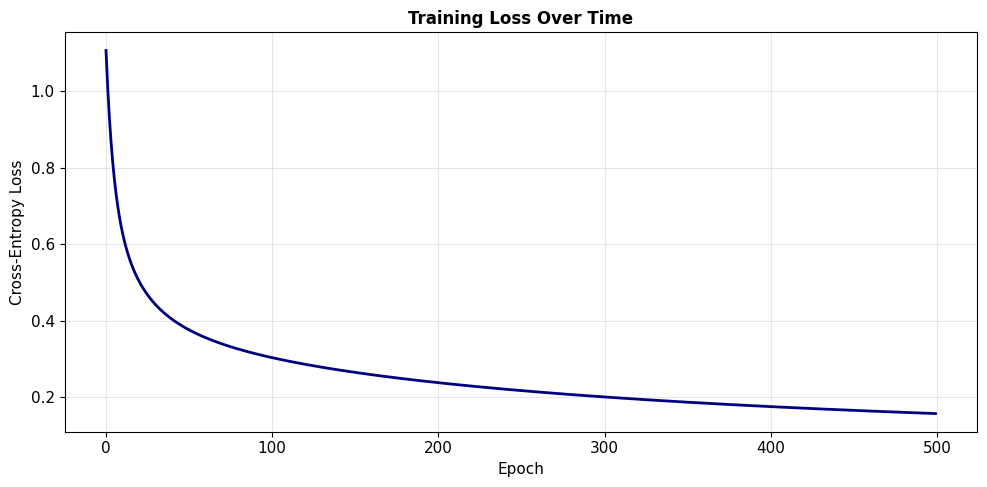

🔍 The loss decreases smoothly - gradient descent is working!


In [14]:
# Plot training loss
plt.figure(figsize=(10, 5))
plt.plot(history['epoch'], history['loss'], linewidth=2, color='navy')
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('Cross-Entropy Loss', fontsize=11)
plt.title('Training Loss Over Time', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("🔍 The loss decreases smoothly - gradient descent is working!")

## Part 10: Making Predictions

Let's see what our model predicts for some test examples!

In [15]:
# Predict on test set
test_probs = model.predict_proba(X_test)
test_preds = model.predict(X_test)

# Show first 10 predictions
print("First 10 Test Predictions:\n")
print(f"{'Index':<6} {'True':<12} {'Predicted':<12} {'Probabilities':<30} {'Correct?'}")
print("="*80)

for i in range(10):
    true_class = class_names[y_test[i]]
    pred_class = class_names[test_preds[i]]
    probs_str = np.array2string(test_probs[i], precision=2, separator=', ')
    correct = "✓" if y_test[i] == test_preds[i] else "✗"
    print(f"{i:<6} {true_class:<12} {pred_class:<12} {probs_str:<30} {correct}")

First 10 Test Predictions:

Index  True         Predicted    Probabilities                  Correct?
0      virginica    virginica    [4.13e-05, 1.34e-01, 8.66e-01] ✓
1      versicolor   versicolor   [0.01, 0.72, 0.27]             ✓
2      virginica    versicolor   [0.  , 0.59, 0.41]             ✗
3      versicolor   virginica    [0.02, 0.44, 0.53]             ✗
4      virginica    virginica    [0.  , 0.31, 0.68]             ✓
5      virginica    virginica    [5.02e-05, 2.40e-02, 9.76e-01] ✓
6      versicolor   versicolor   [0.01, 0.92, 0.07]             ✓
7      versicolor   versicolor   [0.03, 0.93, 0.04]             ✓
8      setosa       setosa       [9.64e-01, 3.56e-02, 2.26e-05] ✓
9      virginica    virginica    [1.28e-04, 4.96e-02, 9.50e-01] ✓


### Confidence Analysis

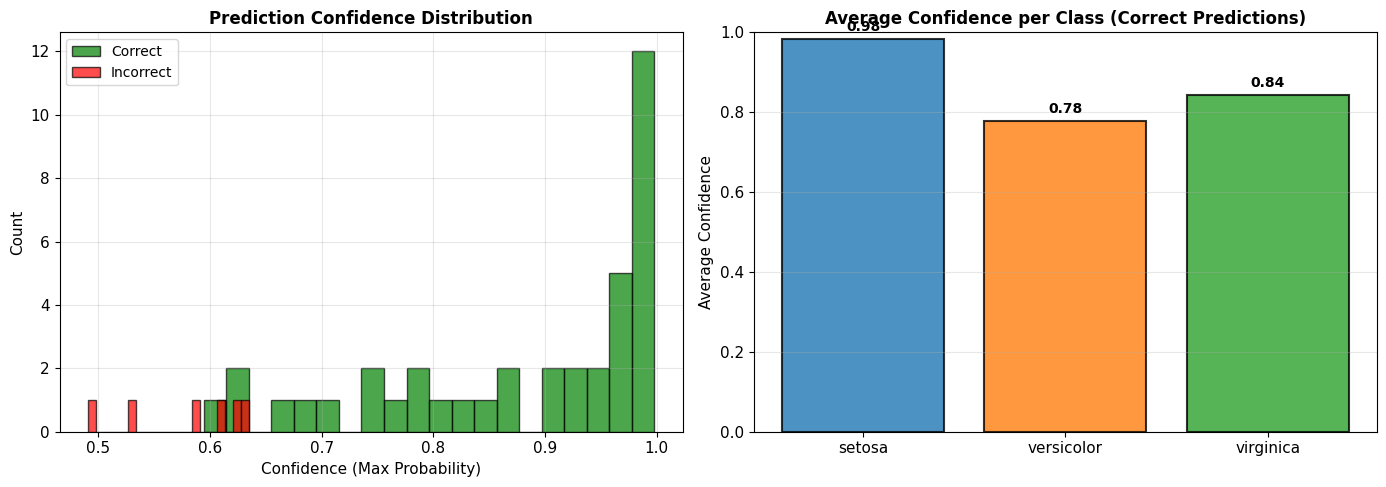


Average confidence on correct predictions: 87.77%
Average confidence on incorrect predictions: 58.01%


In [16]:
# Analyze prediction confidence
max_probs = np.max(test_probs, axis=1)  # Confidence = max probability
correct = (test_preds == y_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Confidence distribution
axes[0].hist(max_probs[correct], bins=20, alpha=0.7, label='Correct', color='green', edgecolor='black')
axes[0].hist(max_probs[~correct], bins=20, alpha=0.7, label='Incorrect', color='red', edgecolor='black')
axes[0].set_xlabel('Confidence (Max Probability)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('Prediction Confidence Distribution', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2: Average confidence per class
avg_conf_per_class = []
for i in range(num_classes):
    mask = (test_preds == i) & correct
    if mask.sum() > 0:
        avg_conf_per_class.append(max_probs[mask].mean())
    else:
        avg_conf_per_class.append(0)

axes[1].bar(class_names, avg_conf_per_class, alpha=0.8, color=['#1f77b4', '#ff7f0e', '#2ca02c'], 
           edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('Average Confidence', fontsize=11)
axes[1].set_title('Average Confidence per Class (Correct Predictions)', fontsize=12, fontweight='bold')
axes[1].set_ylim([0, 1])
axes[1].grid(True, alpha=0.3, axis='y')
for i, conf in enumerate(avg_conf_per_class):
    axes[1].text(i, conf + 0.02, f'{conf:.2f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nAverage confidence on correct predictions: {max_probs[correct].mean():.2%}")
if (~correct).sum() > 0:
    print(f"Average confidence on incorrect predictions: {max_probs[~correct].mean():.2%}")
else:
    print("All predictions correct!")

## Part 11: Confusion Matrix

A **confusion matrix** shows which classes get confused with each other.

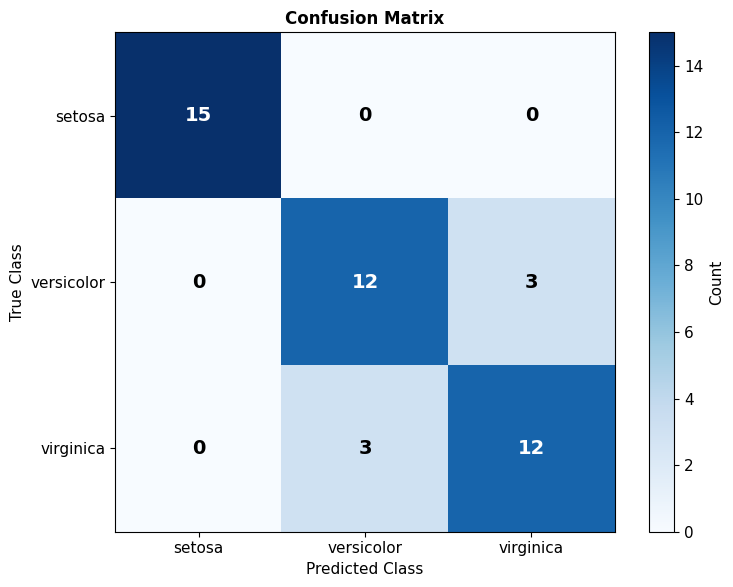

🔍 Reading the confusion matrix:
  • Diagonal = correct predictions
  • Off-diagonal = misclassifications
  • Most misclassified class: versicolor (3 errors)


In [17]:
# Compute confusion matrix
confusion = np.zeros((num_classes, num_classes), dtype=int)
for true_label, pred_label in zip(y_test, test_preds):
    confusion[true_label, pred_label] += 1

# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(confusion, cmap='Blues')

# Add labels
ax.set_xticks(np.arange(num_classes))
ax.set_yticks(np.arange(num_classes))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)
ax.set_xlabel('Predicted Class', fontsize=11)
ax.set_ylabel('True Class', fontsize=11)
ax.set_title('Confusion Matrix', fontsize=12, fontweight='bold')

# Add text annotations
for i in range(num_classes):
    for j in range(num_classes):
        text = ax.text(j, i, confusion[i, j], ha="center", va="center", 
                      color="white" if confusion[i, j] > confusion.max()/2 else "black", 
                      fontsize=14, fontweight='bold')

plt.colorbar(im, ax=ax, label='Count')
plt.tight_layout()
plt.show()

print("🔍 Reading the confusion matrix:")
print("  • Diagonal = correct predictions")
print("  • Off-diagonal = misclassifications")

# Find which class has most misclassifications
misclass_per_class = confusion.sum(axis=1) - np.diag(confusion)
if misclass_per_class.max() > 0:
    most_confused_class = np.argmax(misclass_per_class)
    print(f"  • Most misclassified class: {class_names[most_confused_class]} ({int(misclass_per_class[most_confused_class])} errors)")
else:
    print("  • Perfect classification - no errors!")

## Part 12: Decision Boundaries (2D Visualization)

Let's visualize how the model divides the feature space. For visualization, we'll use just 2 features and retrain.

In [18]:
# Use only 2 features for visualization (petal length and width)
X_2d = X[:, 2:4]  # Petal length and width
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y, test_size=0.3, random_state=42, stratify=y
)

# Standardize
mean_2d = X_train_2d.mean(axis=0)
std_2d = X_train_2d.std(axis=0)
X_train_2d = (X_train_2d - mean_2d) / std_2d
X_test_2d = (X_test_2d - mean_2d) / std_2d

# One-hot encode
y_train_onehot_2d = one_hot_encode(y_train_2d, num_classes)

# Train 2D model
model_2d = MulticlassLogisticRegression(2, num_classes)
print("Training 2D model for visualization...\n")
history_2d = model_2d.train(
    X_train_2d, y_train_onehot_2d, 
    learning_rate=0.1, 
    num_epochs=500, 
    verbose=False
)
test_acc_2d = model_2d.accuracy(X_test_2d, y_test_2d)
print(f"✓ 2D Model Test Accuracy: {test_acc_2d:.2%}")

Training 2D model for visualization...

✓ 2D Model Test Accuracy: 91.11%


### Visualizing Decision Boundaries

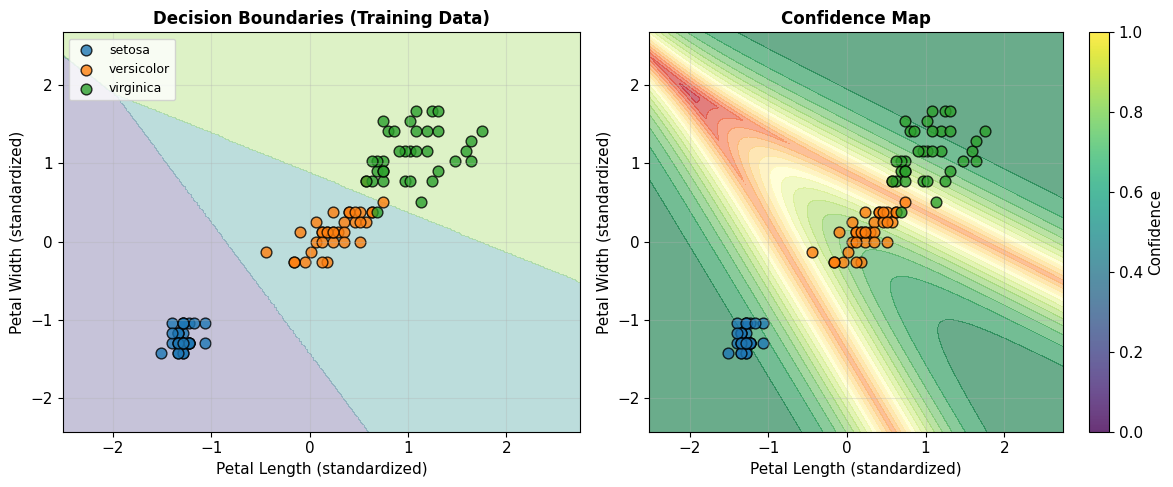


🔍 Observations:
  • Linear decision boundaries separate classes
  • Confidence is highest far from boundaries
  • Near boundaries, model is less certain


In [19]:
# Create mesh for decision boundary
h = 0.02  # Step size
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Predict on mesh
Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(12, 5))

# Plot 1: Decision boundaries with regions
plt.subplot(1, 2, 1)
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis', levels=np.arange(num_classes+1)-0.5)
for i, class_name in enumerate(class_names):
    mask = y_train_2d == i
    plt.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1], s=60, label=class_name, 
               alpha=0.8, edgecolors='black', linewidth=1)
plt.xlabel('Petal Length (standardized)', fontsize=11)
plt.ylabel('Petal Width (standardized)', fontsize=11)
plt.title('Decision Boundaries (Training Data)', fontsize=12, fontweight='bold')
plt.legend(loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)

# Plot 2: Confidence heatmap
plt.subplot(1, 2, 2)
probs_mesh = model_2d.predict_proba(np.c_[xx.ravel(), yy.ravel()])
confidence_mesh = np.max(probs_mesh, axis=1).reshape(xx.shape)
plt.contourf(xx, yy, confidence_mesh, alpha=0.6, cmap='RdYlGn', levels=20)
for i, class_name in enumerate(class_names):
    mask = y_train_2d == i
    plt.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1], s=60, label=class_name, 
               alpha=0.8, edgecolors='black', linewidth=1)
plt.xlabel('Petal Length (standardized)', fontsize=11)
plt.ylabel('Petal Width (standardized)', fontsize=11)
plt.title('Confidence Map', fontsize=12, fontweight='bold')
plt.colorbar(label='Confidence')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🔍 Observations:")
print("  • Linear decision boundaries separate classes")
print("  • Confidence is highest far from boundaries")
print("  • Near boundaries, model is less certain")

## Part 13: Comparing Binary and Multiclass

Let's explicitly connect back to binary classification!

In [20]:
# Create comparison table
comparison = [
    ["Number of classes", "2", "K (≥ 2)"],
    ["Output activation", "Sigmoid", "Softmax"],
    ["Output range", "[0, 1] (single prob.)", "[0, 1]ᴷ (prob. vector)"],
    ["Output constraint", "p + (1-p) = 1", "Σpᵢ = 1"],
    ["Loss function", "Binary cross-entropy", "Categorical cross-entropy"],
    ["Label encoding", "0 or 1 (integers)", "One-hot vectors"],
    ["Model output shape", "(n, 1) or (n,)", "(n, K)"],
    ["Decision boundary", "1 hyperplane", "K-1 hyperplanes"],
]

print("\n" + "="*80)
print("BINARY vs MULTICLASS CLASSIFICATION")
print("="*80)
print(f"\n{'Aspect':<25} {'Binary':<25} {'Multiclass':<25}")
print("-"*80)
for row in comparison:
    print(f"{row[0]:<25} {row[1]:<25} {row[2]:<25}")
print("="*80)


BINARY vs MULTICLASS CLASSIFICATION

Aspect                    Binary                    Multiclass               
--------------------------------------------------------------------------------
Number of classes         2                         K (≥ 2)                  
Output activation         Sigmoid                   Softmax                  
Output range              [0, 1] (single prob.)     [0, 1]ᴷ (prob. vector)   
Output constraint         p + (1-p) = 1             Σpᵢ = 1                  
Loss function             Binary cross-entropy      Categorical cross-entropy
Label encoding            0 or 1 (integers)         One-hot vectors          
Model output shape        (n, 1) or (n,)            (n, K)                   
Decision boundary         1 hyperplane              K-1 hyperplanes          


### The Beautiful Connection

**Binary is a special case of multiclass!**

For 2 classes, softmax reduces to sigmoid:

$$\text{softmax}([z_0, z_1])_1 = \frac{e^{z_1}}{e^{z_0} + e^{z_1}} = \frac{1}{1 + e^{-(z_1 - z_0)}} = \sigma(z_1 - z_0)$$

And categorical cross-entropy reduces to binary cross-entropy!

### Verifying the Connection

In [21]:
# Demonstrate that 2-class softmax = sigmoid
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Test with random logits
z0, z1 = 1.5, 2.8
logits_2class = np.array([z0, z1])

# Method 1: Softmax for 2 classes
probs_softmax = softmax(logits_2class)

# Method 2: Sigmoid on difference
prob_class1_sigmoid = sigmoid(z1 - z0)

print("Demonstrating Binary = Multiclass (K=2):\n")
print(f"Logits: z₀={z0}, z₁={z1}\n")
print(f"Softmax output: {probs_softmax}")
print(f"  P(class 0) = {probs_softmax[0]:.6f}")
print(f"  P(class 1) = {probs_softmax[1]:.6f}")
print(f"\nSigmoid on difference: σ(z₁ - z₀) = {prob_class1_sigmoid:.6f}")
print(f"\nDifference: {abs(probs_softmax[1] - prob_class1_sigmoid):.10f}")
print("\n✓ They're the same! Binary is just multiclass with K=2.")

Demonstrating Binary = Multiclass (K=2):

Logits: z₀=1.5, z₁=2.8

Softmax output: [0.21416502 0.78583498]
  P(class 0) = 0.214165
  P(class 1) = 0.785835

Sigmoid on difference: σ(z₁ - z₀) = 0.785835

Difference: 0.0000000000

✓ They're the same! Binary is just multiclass with K=2.


## Part 14: Practical Considerations

### When to Use Multiclass Classification?

✅ **Use multiclass when:**
- Classes are **mutually exclusive** (each example belongs to exactly one class)
- Examples: species classification, digit recognition, single-label sentiment

❌ **Don't use multiclass when:**
- Classes can **overlap** (example can belong to multiple classes)
- Examples: image tags ("dog" and "outdoor"), disease diagnosis
- Use **multilabel classification** instead (multiple binary classifiers)

### Common Pitfalls

1. **Forgetting to standardize features**: Gradient descent struggles without it
2. **Using integer labels directly**: Need one-hot encoding for cross-entropy
3. **Imbalanced classes**: Some classes have many more examples
4. **Confusing softmax and sigmoid**: Softmax for multiclass, sigmoid for binary
5. **Not checking for numerical stability**: Add epsilon to prevent log(0)

### Class Imbalance Example

In [22]:
# Simulate imbalanced dataset
print("Example: Effect of Class Imbalance\n")

# Balanced (Iris is already balanced)
balanced_dist = np.array([50, 50, 50])
print(f"Balanced dataset:   {balanced_dist} (equal representation)")
print(f"  Baseline accuracy if always predicting most common class: {balanced_dist.max() / balanced_dist.sum():.1%}\n")

# Imbalanced
imbalanced_dist = np.array([10, 20, 120])
print(f"Imbalanced dataset: {imbalanced_dist} (skewed representation)")
print(f"  Baseline accuracy if always predicting most common class: {imbalanced_dist.max() / imbalanced_dist.sum():.1%}")
print("\n⚠️ With imbalance, accuracy can be misleading!")
print("   Solution: Use per-class metrics (precision, recall, F1) or balance the dataset")

Example: Effect of Class Imbalance

Balanced dataset:   [50 50 50] (equal representation)
  Baseline accuracy if always predicting most common class: 33.3%

Imbalanced dataset: [ 10  20 120] (skewed representation)
  Baseline accuracy if always predicting most common class: 80.0%

⚠️ With imbalance, accuracy can be misleading!
   Solution: Use per-class metrics (precision, recall, F1) or balance the dataset


## Part 15: Summary & Key Takeaways

Congratulations! You've mastered multiclass classification from scratch.

### 🎯 What You've Learned

1. **Softmax Function**
   - Converts raw scores (logits) to probabilities
   - Ensures outputs are positive and sum to 1
   - Formula: $\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_j e^{z_j}}$
   - Temperature parameter controls confidence

2. **One-Hot Encoding**
   - Converts class labels to probability distributions
   - Enables comparison with model predictions
   - Class $k$ → vector with 1 at position $k$, 0 elsewhere

3. **Categorical Cross-Entropy**
   - Loss function for multiclass classification
   - Measures distance between predicted and true distributions
   - Formula: $L = -\sum_i y_i \log(\hat{y}_i)$
   - Simplifies to: $L = -\log(\hat{y}_{\text{true class}})$

4. **Multiclass Logistic Regression**
   - Linear model for multiple classes
   - Trained with gradient descent
   - Creates linear decision boundaries

5. **Binary → Multiclass Bridge**
   - Binary classification is multiclass with K=2
   - Sigmoid is a special case of softmax
   - Binary cross-entropy is categorical cross-entropy for K=2

### 💡 The Big Picture

**Softmax + cross-entropy is THE standard for multiclass classification** because:
- Probabilistic interpretation (outputs are probabilities)
- Mathematically principled (information theory)
- Smooth gradients (good for optimization)
- Extends naturally from binary classification
- Works with neural networks (next step!)

### 🚀 What's Next?

Now that you understand multiclass classification, you can:
- **Build neural networks**: Replace linear layer with deep networks
- **Tackle real problems**: Image classification, text classification, etc.
- **Explore advanced topics**: Attention, transformers (all use softmax!)
- **Understand modern architectures**: ResNets, ViTs, BERT (all end with softmax)

### 🤔 Final Reflection Questions

1. Why is softmax called "soft"? What's the "hard" version?
2. What happens if you use sigmoid instead of softmax for 3+ classes?
3. Could you implement this with PyTorch? (Hint: `torch.nn.Linear` + `torch.nn.functional.softmax`)
4. How would you extend this to handle 1000 classes? (Hint: same algorithm!)

---

**Well done!** 🎉 You now have deep intuitions about multiclass classification and are ready to tackle neural networks!